(255347, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 1

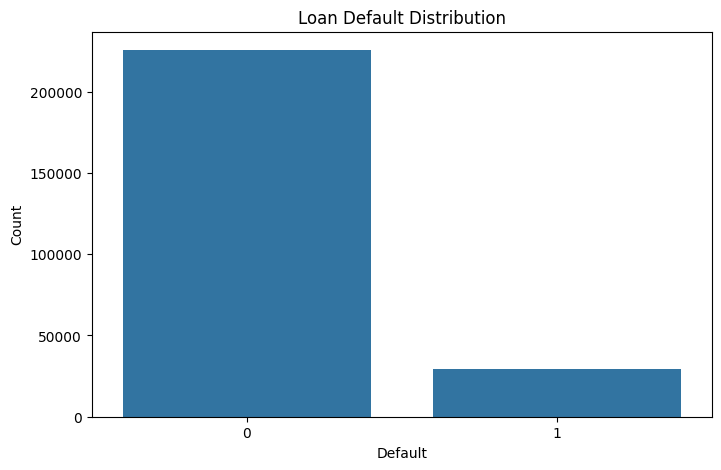

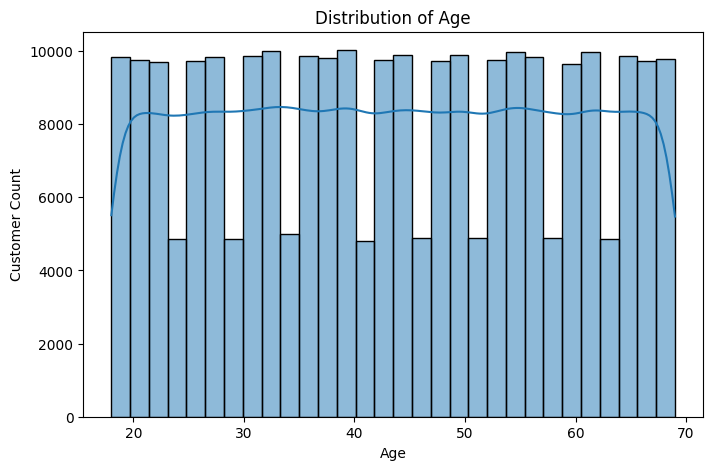

Maximum Age: 69
Minimum Age: 18


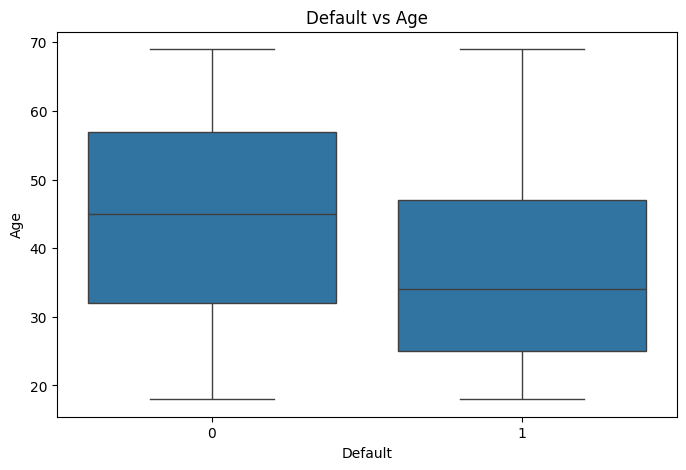

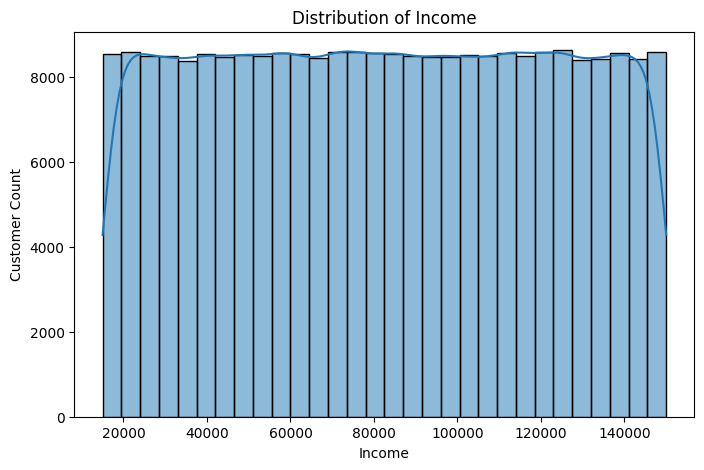

Maximum Income: 149999
Minimum Income: 15000


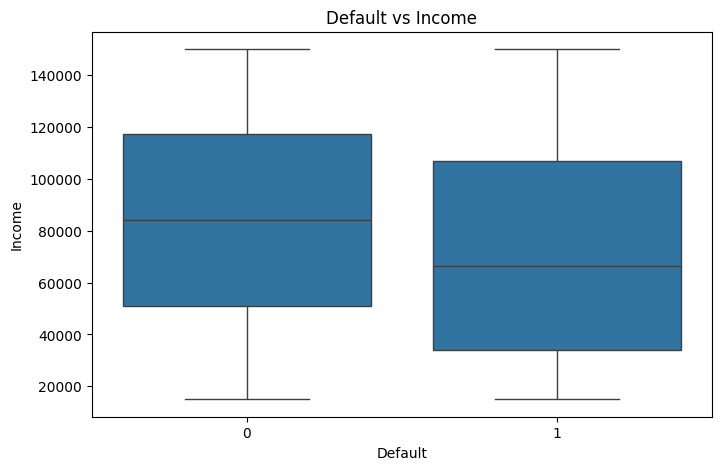

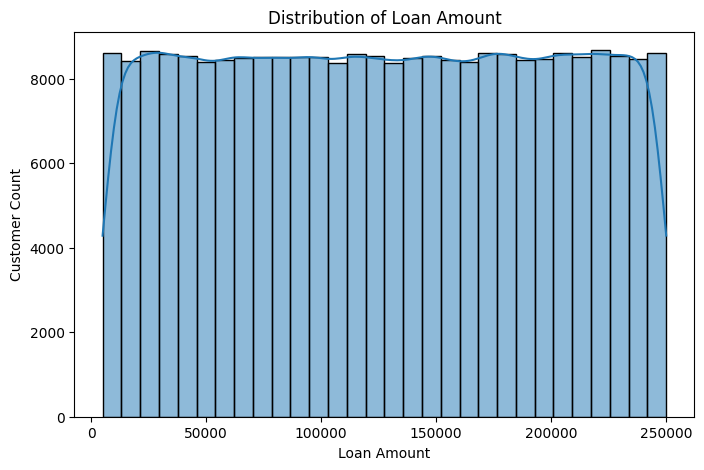

Maximum Loan Amount: 249999
Minimum Loan Amount: 5000


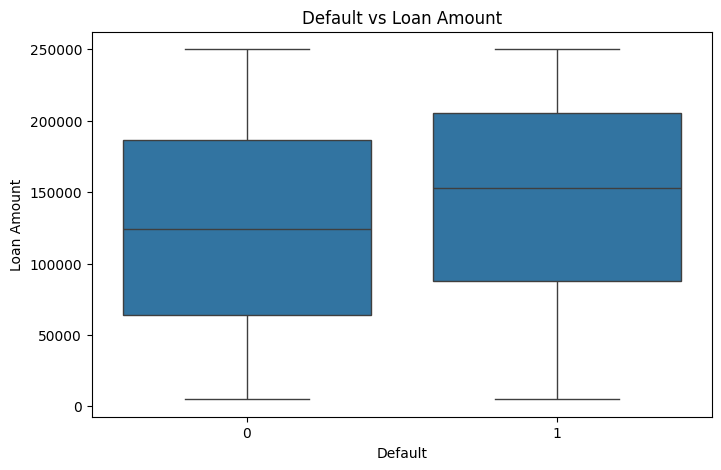

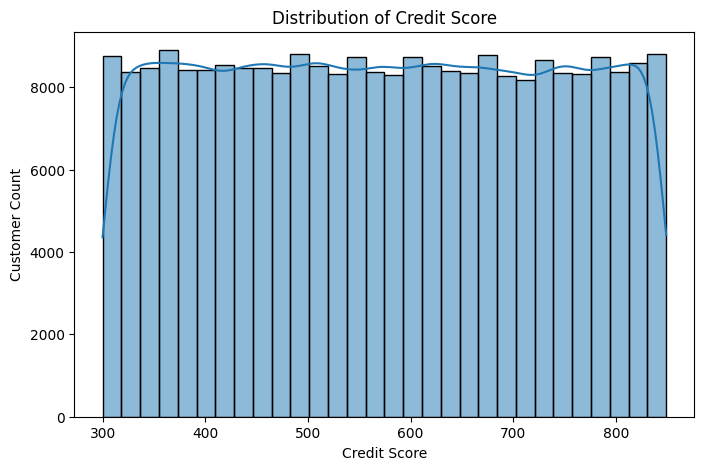

Maximum Credit Score: 849
Minimum Credit Score: 300


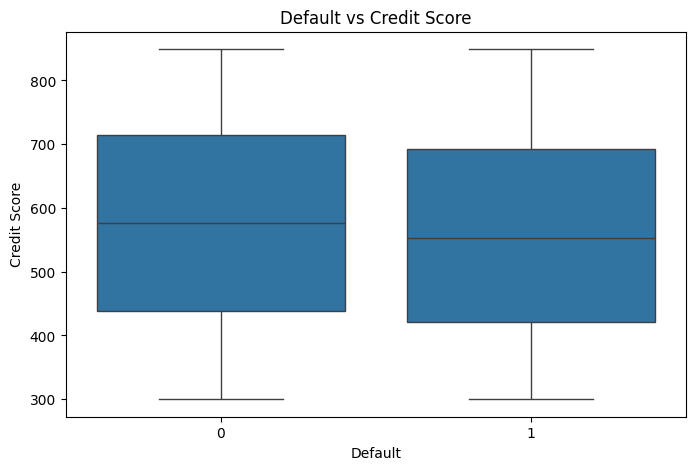

count    255347.000000
mean        574.264346
std         158.903867
min         300.000000
25%         437.000000
50%         574.000000
75%         712.000000
max         849.000000
Name: CreditScore, dtype: float64
count    255347.000000
mean     127578.865512
std       70840.706142
min        5000.000000
25%       66156.000000
50%      127556.000000
75%      188985.000000
max      249999.000000
Name: LoanAmount, dtype: float64
count    255347.000000
mean      82499.304597
std       38963.013729
min       15000.000000
25%       48825.500000
50%       82466.000000
75%      116219.000000
max      149999.000000
Name: Income, dtype: float64


In [10]:
# ============================================================
# PART 1 : IMPORTS + DATA UNDERSTANDING + EDA
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)
from sklearn.cluster import KMeans

# Load Dataset

df = pd.read_csv(
    "/kaggle/input/datasets/shlok192980707/loan-dataset/Loan_default.csv"
)

# Basic Information

print(df.shape)

print(df.info())

print(df.head())

print(df.isnull().sum())

# Default Distribution

print(df['Default'].value_counts())

plt.figure(figsize=(8,5))
sns.countplot(x='Default', data=df)
plt.xlabel('Default')
plt.ylabel('Count')
plt.title('Loan Default Distribution')
plt.show()

# Age Distribution

plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30, kde=True)
plt.xlabel('Age')
plt.ylabel('Customer Count')
plt.title('Distribution of Age')
plt.show()

print("Maximum Age:", df['Age'].max())
print("Minimum Age:", df['Age'].min())

# Age vs Default

plt.figure(figsize=(8,5))
sns.boxplot(x='Default', y='Age', data=df)
plt.xlabel('Default')
plt.ylabel('Age')
plt.title('Default vs Age')
plt.show()

# Income Distribution

plt.figure(figsize=(8,5))
sns.histplot(df['Income'], bins=30, kde=True)
plt.xlabel('Income')
plt.ylabel('Customer Count')
plt.title('Distribution of Income')
plt.show()

print("Maximum Income:", df['Income'].max())
print("Minimum Income:", df['Income'].min())

# Income vs Default

plt.figure(figsize=(8,5))
sns.boxplot(x='Default', y='Income', data=df)
plt.xlabel('Default')
plt.ylabel('Income')
plt.title('Default vs Income')
plt.show()

# Loan Amount Distribution

plt.figure(figsize=(8,5))
sns.histplot(df['LoanAmount'], bins=30, kde=True)
plt.xlabel('Loan Amount')
plt.ylabel('Customer Count')
plt.title('Distribution of Loan Amount')
plt.show()

print("Maximum Loan Amount:", df['LoanAmount'].max())
print("Minimum Loan Amount:", df['LoanAmount'].min())

# Loan Amount vs Default

plt.figure(figsize=(8,5))
sns.boxplot(x='Default', y='LoanAmount', data=df)
plt.xlabel('Default')
plt.ylabel('Loan Amount')
plt.title('Default vs Loan Amount')
plt.show()

# Credit Score Distribution

plt.figure(figsize=(8,5))
sns.histplot(df['CreditScore'], bins=30, kde=True)
plt.xlabel('Credit Score')
plt.ylabel('Customer Count')
plt.title('Distribution of Credit Score')
plt.show()

print("Maximum Credit Score:", df['CreditScore'].max())
print("Minimum Credit Score:", df['CreditScore'].min())

# Credit Score vs Default

plt.figure(figsize=(8,5))
sns.boxplot(x='Default', y='CreditScore', data=df)
plt.xlabel('Default')
plt.ylabel('Credit Score')
plt.title('Default vs Credit Score')
plt.show()

print(df['CreditScore'].describe())
print(df['LoanAmount'].describe())
print(df['Income'].describe())

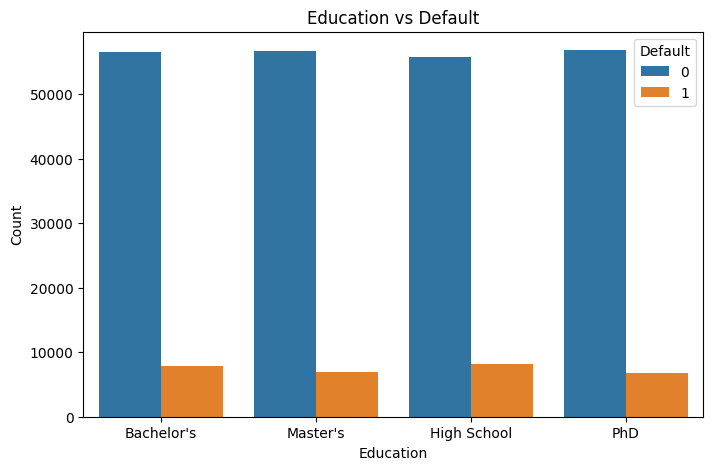

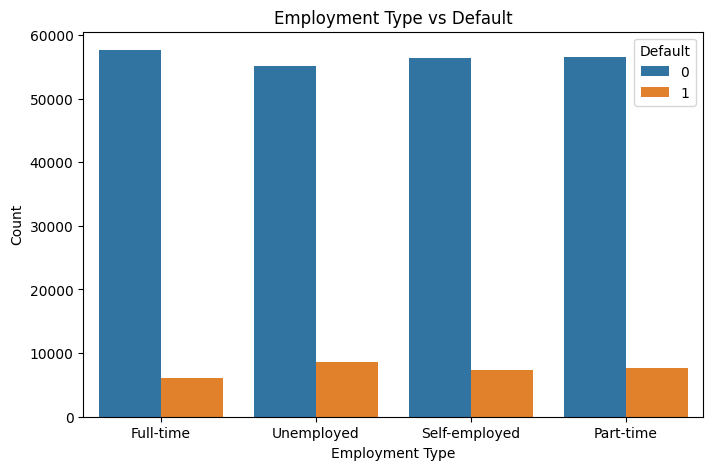

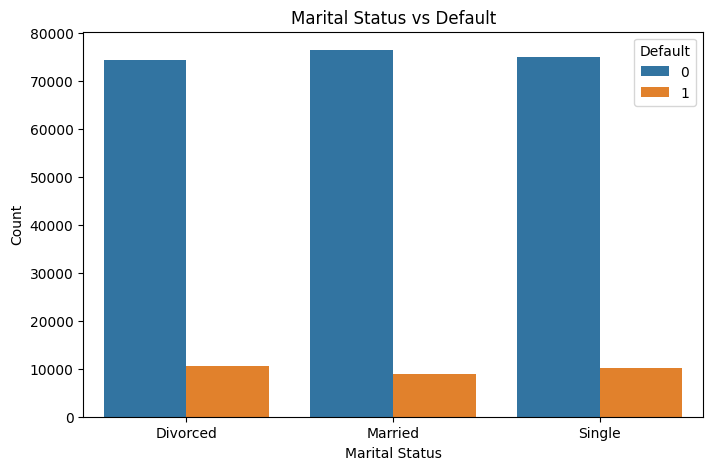

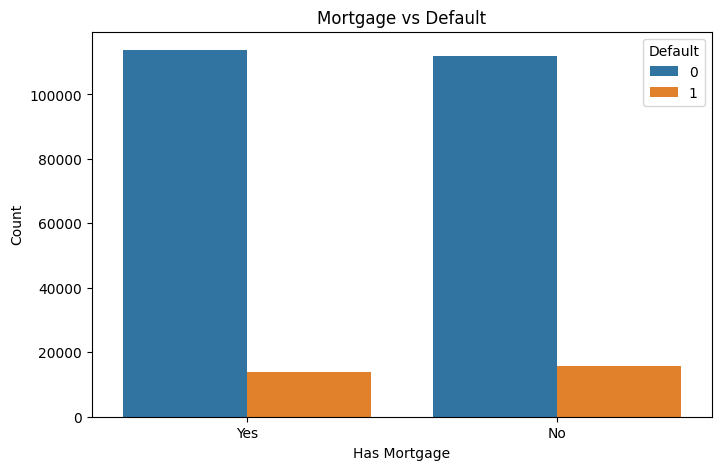

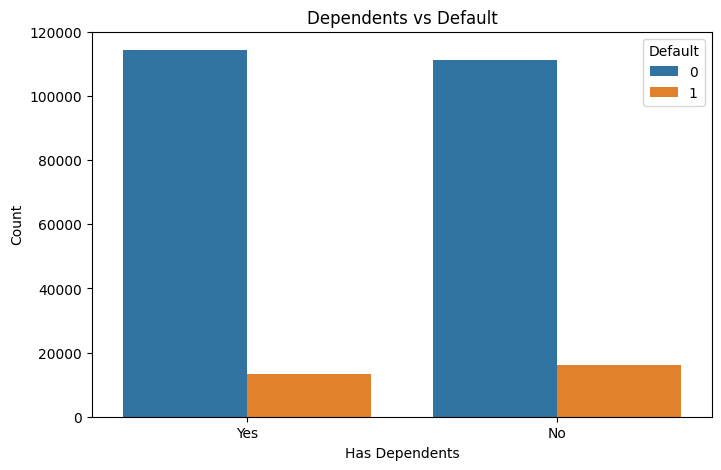

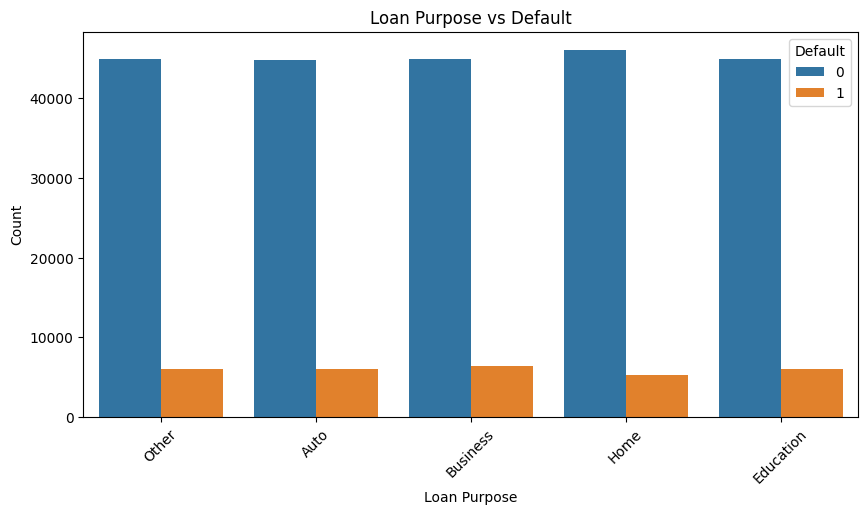

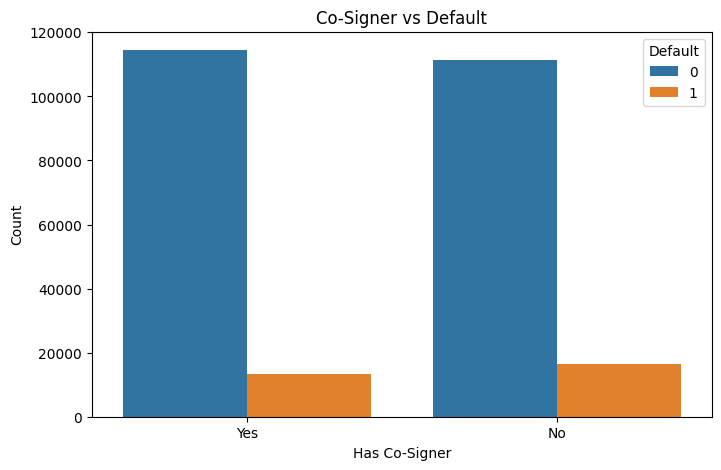

Default
0    83899.165995
1    71844.722659
Name: Income, dtype: float64
Default
0    576.232270
1    559.286143
Name: CreditScore, dtype: float64


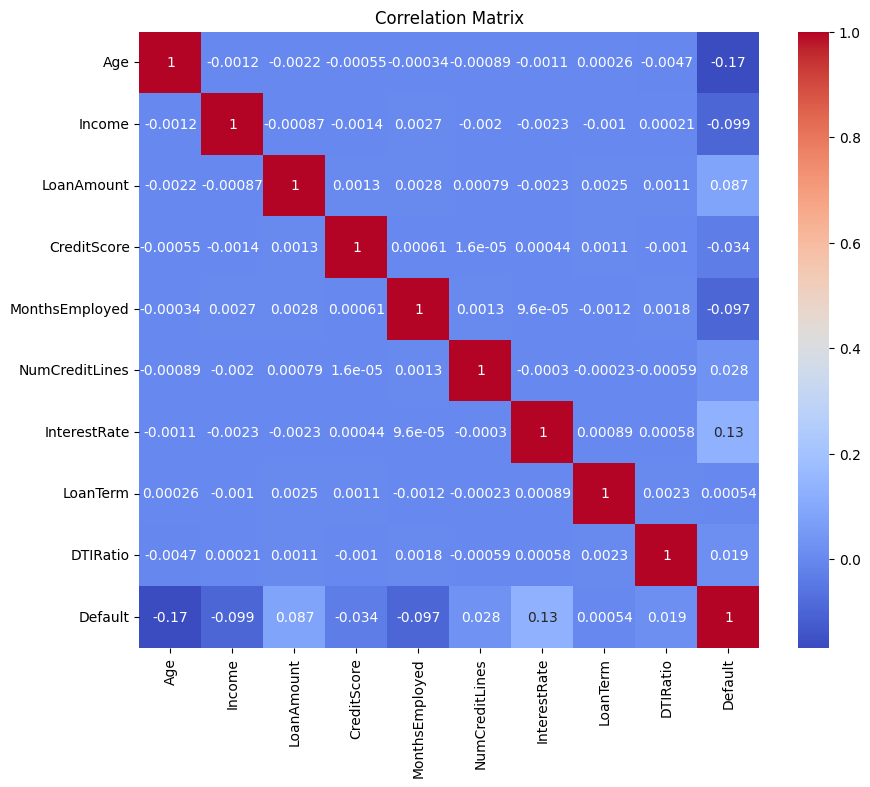

Default             0         1
Education                      
Bachelor's   0.878989  0.121011
High School  0.871211  0.128789
Master's     0.891283  0.108717
PhD          0.894140  0.105860
Default                0         1
EmploymentType                    
Full-time       0.905366  0.094634
Part-time       0.880348  0.119652
Self-employed   0.885380  0.114620
Unemployed      0.864471  0.135529


In [11]:
# ============================================================
# PART 2 : CATEGORICAL ANALYSIS + CORRELATION
# ============================================================

# Education vs Default

plt.figure(figsize=(8,5))
sns.countplot(x='Education', hue='Default', data=df)
plt.xlabel('Education')
plt.ylabel('Count')
plt.title('Education vs Default')
plt.show()

# Employment Type vs Default

plt.figure(figsize=(8,5))
sns.countplot(x='EmploymentType', hue='Default', data=df)
plt.xlabel('Employment Type')
plt.ylabel('Count')
plt.title('Employment Type vs Default')
plt.show()

# Marital Status vs Default

plt.figure(figsize=(8,5))
sns.countplot(x='MaritalStatus', hue='Default', data=df)
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.title('Marital Status vs Default')
plt.show()

# Mortgage vs Default

plt.figure(figsize=(8,5))
sns.countplot(x='HasMortgage', hue='Default', data=df)
plt.xlabel('Has Mortgage')
plt.ylabel('Count')
plt.title('Mortgage vs Default')
plt.show()

# Dependents vs Default

plt.figure(figsize=(8,5))
sns.countplot(x='HasDependents', hue='Default', data=df)
plt.xlabel('Has Dependents')
plt.ylabel('Count')
plt.title('Dependents vs Default')
plt.show()

# Loan Purpose vs Default

plt.figure(figsize=(10,5))
sns.countplot(x='LoanPurpose', hue='Default', data=df)
plt.xlabel('Loan Purpose')
plt.ylabel('Count')
plt.title('Loan Purpose vs Default')
plt.xticks(rotation=45)
plt.show()

# Co-Signer vs Default

plt.figure(figsize=(8,5))
sns.countplot(x='HasCoSigner', hue='Default', data=df)
plt.xlabel('Has Co-Signer')
plt.ylabel('Count')
plt.title('Co-Signer vs Default')
plt.show()

# Average Income by Default

avg_income = df.groupby('Default')['Income'].mean()

print(avg_income)

# Average Credit Score by Default

avg_credit = df.groupby('Default')['CreditScore'].mean()

print(avg_credit)

# Correlation Matrix

numerical_cols = [
    'Age',
    'Income',
    'LoanAmount',
    'CreditScore',
    'MonthsEmployed',
    'NumCreditLines',
    'InterestRate',
    'LoanTerm',
    'DTIRatio',
    'Default'
]

correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm'
)
plt.title('Correlation Matrix')
plt.show()

# Education-wise Default Percentage

education_default = pd.crosstab(
    df['Education'],
    df['Default'],
    normalize='index'
)

print(education_default)

# Employment-wise Default Percentage

employment_default = pd.crosstab(
    df['EmploymentType'],
    df['Default'],
    normalize='index'
)

print(employment_default)

In [12]:
# ============================================================
# PART 3 : DATA CLEANING + PREPROCESSING
# ============================================================

# Remove Loan ID

df_model = df.drop(
    'LoanID',
    axis=1
)

# Check Missing Values

print(df_model.isnull().sum())

# Remove Missing Values

df_model = df_model.dropna()

# Target Variable

Y = df_model['Default']

# Features

X = df_model.drop(
    'Default',
    axis=1
)

# One-Hot Encoding

categorical_columns = X.select_dtypes(
    include='object'
).columns

X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

# Train-Test Split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42,
    stratify=Y
)

# SMOTE

from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

X_train, Y_train = smote.fit_resample(
    X_train,
    Y_train
)

print("After SMOTE:")

print(
    pd.Series(Y_train).value_counts()
)

print("Training Shape:", X_train.shape)

print("Testing Shape:", X_test.shape)

print("Features After Encoding:")

print(X.columns.tolist())

print("Total Features:")

print(len(X.columns))

Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64
After SMOTE:
Default
0    180555
1    180555
Name: count, dtype: int64
Training Shape: (361110, 24)
Testing Shape: (51070, 24)
Features After Encoding:
['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education_High School', "Education_Master's", 'Education_PhD', 'EmploymentType_Part-time', 'EmploymentType_Self-employed', 'EmploymentType_Unemployed', 'MaritalStatus_Married', 'MaritalStatus_Single', 'HasMortgage_Yes', 'HasDependents_Yes', 'LoanPurpose_Business', 'LoanPurpose_Education', 'LoanPurpose_Home', 'LoanPurpose_Other', 'HasCoSigner_Yes']
Total Features:
24


In [13]:
# ============================================================
# PART 4 : RANDOM FOREST MODEL
# ============================================================

rf_balanced = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf_balanced.fit(
    X_train,
    Y_train
)

y_pred_balanced = rf_balanced.predict(
    X_test
)

accuracy_balanced = accuracy_score(
    Y_test,
    y_pred_balanced
)

cm_balanced = confusion_matrix(
    Y_test,
    y_pred_balanced
)

print("Accuracy:")

print(accuracy_balanced)

print()

print("Confusion Matrix:")

print(cm_balanced)

print()

print("Classification Report:")

print(
    classification_report(
        Y_test,
        y_pred_balanced
    )
)

# Tuned Random Forest

rf_tuned = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    class_weight='balanced'
)

rf_tuned.fit(
    X_train,
    Y_train
)

y_pred_tuned = rf_tuned.predict(
    X_test
)

print("Tuned Random Forest Accuracy:")

print(
    accuracy_score(
        Y_test,
        y_pred_tuned
    )
)

print()

print("Tuned Random Forest Report:")

print(
    classification_report(
        Y_test,
        y_pred_tuned
    )
)

Accuracy:
0.8731936557665949

Confusion Matrix:
[[44037  1102]
 [ 5374   557]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.98      0.93     45139
           1       0.34      0.09      0.15      5931

    accuracy                           0.87     51070
   macro avg       0.61      0.53      0.54     51070
weighted avg       0.83      0.87      0.84     51070

Tuned Random Forest Accuracy:
0.8220090072449578

Tuned Random Forest Report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90     45139
           1       0.22      0.21      0.21      5931

    accuracy                           0.82     51070
   macro avg       0.56      0.56      0.56     51070
weighted avg       0.82      0.82      0.82     51070



In [ ]:
# ============================================================
# PART 5 : FEATURE IMPORTANCE + HYPERPARAMETER TUNING
# ============================================================

feature_importance = pd.DataFrame({

    'Features': X.columns,

    'Importance': rf_tuned.feature_importances_

})

feature_importance = feature_importance.sort_values(

    by='Importance',

    ascending=False

)

print(feature_importance.head(30))

# Top Features

top_features = feature_importance.head(20)[
    'Features'
]

X_selected = X[top_features]

X_train_sel, X_test_sel, Y_train_sel, Y_test_sel = train_test_split(

    X_selected,

    Y,

    test_size=0.20,

    random_state=42,

    stratify=Y

)

rf_selected = RandomForestClassifier(

    n_estimators=300,

    max_depth=10,

    random_state=42,

    class_weight='balanced'

)

rf_selected.fit(

    X_train_sel,

    Y_train_sel

)

y_pred_selected = rf_selected.predict(

    X_test_sel

)

print()

print("Top Feature Model Report")

print()

print(
    classification_report(
        Y_test_sel,
        y_pred_selected
    )
)

# Hyperparameter Tuning

n_estimators_list = [

    100,
    200,
    300,
    400,
    500

]

max_depth_list = [

    5,
    10,
    15,
    20

]

results = []

for n_trees in n_estimators_list:

    for depth in max_depth_list:

        rf = RandomForestClassifier(

            n_estimators=n_trees,

            max_depth=depth,

            random_state=42,

            class_weight='balanced'

        )

        rf.fit(
            X_train,
            Y_train
        )

        y_pred = rf.predict(
            X_test
        )

        accuracy = accuracy_score(
            Y_test,
            y_pred
        )

        recall = recall_score(
            Y_test,
            y_pred
        )

        precision = precision_score(
            Y_test,
            y_pred
        )

        f1 = f1_score(
            Y_test,
            y_pred
        )

        results.append({

            'Trees': n_trees,

            'Depth': depth,

            'Accuracy': accuracy,

            'Recall': recall,

            'Precision': precision,

            'F1 Score': f1

        })

result_df = pd.DataFrame(
    results
)

result_df = result_df.sort_values(

    by=['Recall', 'Accuracy'],

    ascending=False

)

print()

print(result_df.head(20))

                        Features  Importance
0                            Age    0.132706
14     EmploymentType_Unemployed    0.098012
6                   InterestRate    0.087904
7                       LoanTerm    0.084690
12      EmploymentType_Part-time    0.075779
13  EmploymentType_Self-employed    0.073234
9          Education_High School    0.055563
4                 MonthsEmployed    0.046455
16          MaritalStatus_Single    0.042011
15         MaritalStatus_Married    0.038731
10            Education_Master's    0.036535
11                 Education_PhD    0.034005
19          LoanPurpose_Business    0.029841
5                 NumCreditLines    0.025684
20         LoanPurpose_Education    0.024262
22             LoanPurpose_Other    0.023561
1                         Income    0.023184
17               HasMortgage_Yes    0.022240
21              LoanPurpose_Home    0.016227
2                     LoanAmount    0.008533
18             HasDependents_Yes    0.007740
23        

In [15]:
# ============================================================
# PART 6A : XGBOOST MODEL
# ============================================================

from xgboost import XGBClassifier

xgb_model = XGBClassifier(

    n_estimators=800,

    max_depth=5,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    min_child_weight=3,

    gamma=0.1,

    random_state=42,

    eval_metric='logloss'

)

xgb_model.fit(

    X_train,

    Y_train

)

y_prob_xgb = xgb_model.predict_proba(
    X_test
)[:,1]

threshold = 0.45

y_pred_xgb = (

    y_prob_xgb >= threshold

).astype(int)

print("Accuracy:")

print(
    accuracy_score(
        Y_test,
        y_pred_xgb
    )
)

print()

print("Classification Report:")

print()

print(
    classification_report(
        Y_test,
        y_pred_xgb
    )
)

Accuracy:
0.8832974348932837

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.98      0.94     45139
           1       0.49      0.13      0.21      5931

    accuracy                           0.88     51070
   macro avg       0.69      0.56      0.57     51070
weighted avg       0.85      0.88      0.85     51070




                         Feature  Importance
7                       LoanTerm    0.093952
12      EmploymentType_Part-time    0.093839
13  EmploymentType_Self-employed    0.086111
21              LoanPurpose_Home    0.079727
15         MaritalStatus_Married    0.073756
11                 Education_PhD    0.069546
10            Education_Master's    0.063751
9          Education_High School    0.061763
14     EmploymentType_Unemployed    0.061015
20         LoanPurpose_Education    0.055464
22             LoanPurpose_Other    0.054920
16          MaritalStatus_Single    0.048427
19          LoanPurpose_Business    0.044291
0                            Age    0.027992
17               HasMortgage_Yes    0.021009
6                   InterestRate    0.014184
5                 NumCreditLines    0.011316
4                 MonthsEmployed    0.009229
18             HasDependents_Yes    0.007694
1                         Income    0.005768


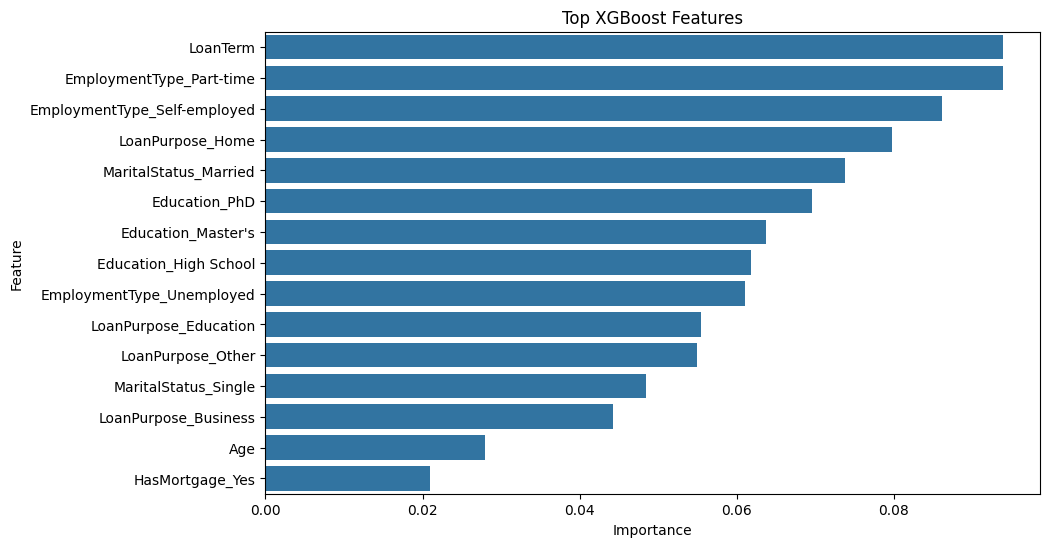

In [16]:
# ============================================================
# PART 6B : XGBOOST FEATURE IMPORTANCE
# ============================================================

xgb_importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance': xgb_model.feature_importances_

})

xgb_importance = xgb_importance.sort_values(

    by='Importance',

    ascending=False

)

print()

print(
    xgb_importance.head(20)
)

plt.figure(figsize=(10,6))

sns.barplot(

    x='Importance',

    y='Feature',

    data=xgb_importance.head(15)

)

plt.title(
    "Top XGBoost Features"
)

plt.show()

In [17]:
# ============================================================
# PART 7 : MODEL COMPARISON
# ============================================================

rf_pred = rf_tuned.predict(
    X_test
)

comparison = pd.DataFrame({

    'Model':[

        'Random Forest',

        'XGBoost'

    ],

    'Accuracy':[

        accuracy_score(
            Y_test,
            rf_pred
        ),

        accuracy_score(
            Y_test,
            y_pred_xgb
        )

    ],

    'Recall':[

        recall_score(
            Y_test,
            rf_pred
        ),

        recall_score(
            Y_test,
            y_pred_xgb
        )

    ],

    'Precision':[

        precision_score(
            Y_test,
            rf_pred
        ),

        precision_score(
            Y_test,
            y_pred_xgb
        )

    ],

    'F1 Score':[

        f1_score(
            Y_test,
            rf_pred
        ),

        f1_score(
            Y_test,
            y_pred_xgb
        )

    ]

})

print()

print("MODEL COMPARISON")

print()

print(comparison)


MODEL COMPARISON

           Model  Accuracy    Recall  Precision  F1 Score
0  Random Forest  0.822009  0.208397   0.219499  0.213804
1        XGBoost  0.883297  0.131344   0.490863  0.207236



MODEL COMPARISON

           Model  Accuracy    Recall  Precision  F1 Score
0  Random Forest  0.865068  0.121396   0.300000  0.172848
1        XGBoost  0.883297  0.131344   0.490863  0.207236

Best Model: XGBoost


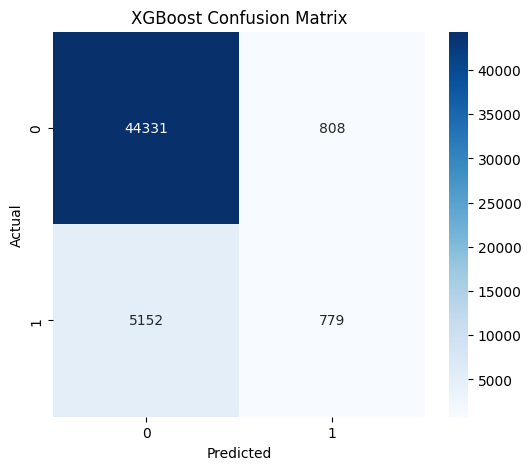


Classification Report

              precision    recall  f1-score   support

           0       0.90      0.98      0.94     45139
           1       0.49      0.13      0.21      5931

    accuracy                           0.88     51070
   macro avg       0.69      0.56      0.57     51070
weighted avg       0.85      0.88      0.85     51070



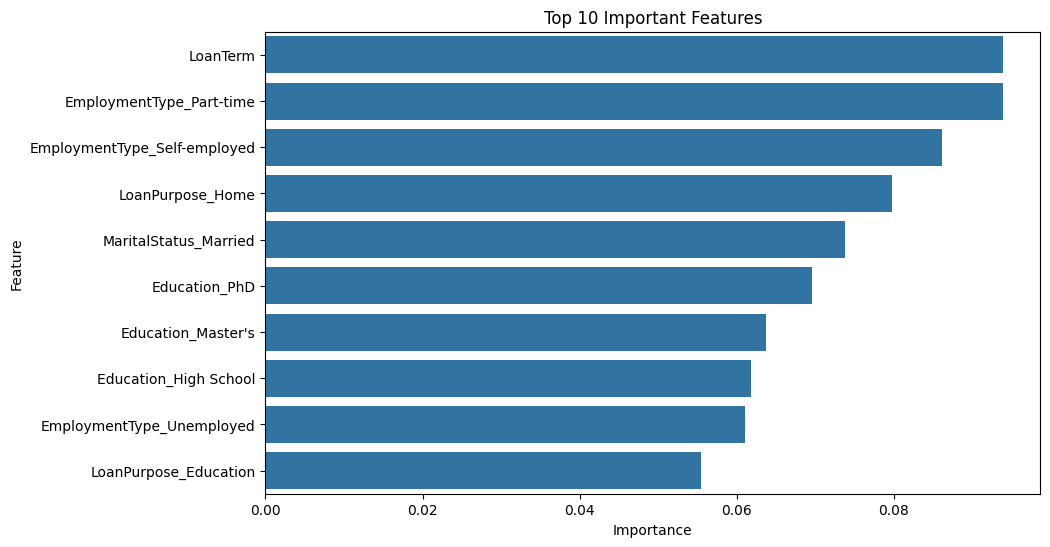


Lecture 6 Completed Successfully


In [20]:
# ============================================================
# PART 8 : FINAL LOAN DEFAULT PREDICTION
# ============================================================

from sklearn.metrics import (

    accuracy_score,

    recall_score,

    precision_score,

    f1_score,

    classification_report,

    confusion_matrix

)

# ============================================================
# RANDOM FOREST MODEL
# ============================================================

rf_model = RandomForestClassifier(

    n_estimators=800,

    max_depth=20,

    min_samples_split=10,

    min_samples_leaf=4,

    class_weight='balanced_subsample',

    random_state=42,

    n_jobs=-1

)

rf_model.fit(

    X_train,

    Y_train

)

rf_pred = rf_model.predict(

    X_test

)

# ============================================================
# XGBOOST MODEL
# ============================================================

xgb_model = XGBClassifier(

    n_estimators=800,

    max_depth=5,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    min_child_weight=3,

    gamma=0.1,

    random_state=42,

    eval_metric='logloss'

)

xgb_model.fit(

    X_train,

    Y_train

)

xgb_prob = xgb_model.predict_proba(

    X_test

)[:,1]

threshold = 0.45

xgb_pred = (

    xgb_prob >= threshold

).astype(int)

# ============================================================
# MODEL COMPARISON
# ============================================================

results_df = pd.DataFrame({

    'Model':[

        'Random Forest',

        'XGBoost'

    ],

    'Accuracy':[

        accuracy_score(

            Y_test,

            rf_pred

        ),

        accuracy_score(

            Y_test,

            xgb_pred

        )

    ],

    'Recall':[

        recall_score(

            Y_test,

            rf_pred

        ),

        recall_score(

            Y_test,

            xgb_pred

        )

    ],

    'Precision':[

        precision_score(

            Y_test,

            rf_pred

        ),

        precision_score(

            Y_test,

            xgb_pred

        )

    ],

    'F1 Score':[

        f1_score(

            Y_test,

            rf_pred

        ),

        f1_score(

            Y_test,

            xgb_pred

        )

    ]

})

print()

print("MODEL COMPARISON")

print()

print(results_df)

# ============================================================
# BEST MODEL
# ============================================================

best_model = results_df.loc[

    results_df['F1 Score'].idxmax(),

    'Model'

]

print()

print("Best Model:", best_model)

# ============================================================
# CONFUSION MATRIX
# ============================================================

plt.figure(figsize=(6,5))

sns.heatmap(

    confusion_matrix(

        Y_test,

        xgb_pred

    ),

    annot=True,

    fmt='d',

    cmap='Blues'

)

plt.title("XGBoost Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print()

print("Classification Report")

print()

print(

    classification_report(

        Y_test,

        xgb_pred

    )

)

# ============================================================
# TOP 10 FEATURES
# ============================================================

importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance': xgb_model.feature_importances_

})

importance = importance.sort_values(

    by='Importance',

    ascending=False

)

plt.figure(figsize=(10,6))

sns.barplot(

    x='Importance',

    y='Feature',

    data=importance.head(10)

)

plt.title("Top 10 Important Features")

plt.show()

print()

print("Lecture 6 Completed Successfully")

# Probability for Entire Dataset

segmentation_data = df.copy()

encoded_data = pd.get_dummies(

    df_model.drop(

        'Default',

        axis=1

    ),

    drop_first=True

)

encoded_data = encoded_data.reindex(

    columns=X.columns,

    fill_value=0

)

segmentation_data['Default Probability'] = (

    xgb_model.predict_proba(

        encoded_data

    )[:,1]

)

[[ 0.08969281 -1.08683299 -0.34149233]
 [-0.82302071 -0.04430887 -0.73166611]
 [ 0.04385438  0.02271487 -0.77571799]
 [-1.30345164 -1.16853758  1.06187463]
 [-1.59285487 -1.67192147  0.36963083]]


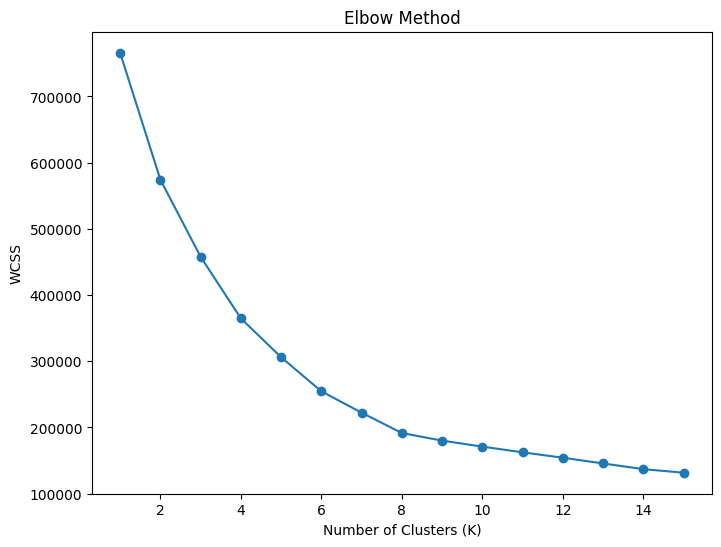


Cluster Summary

               Age         Income     LoanAmount  CreditScore  MonthsEmployed  \
Cluster                                                                         
0        43.570970   89000.850968   69370.870067   425.808638       59.499272   
1        43.431327   75791.534053   70540.358654   724.961302       59.608583   
2        43.522308   45899.316761  185125.419855   547.826617       59.367886   
3        43.468295  119206.625008  184784.300212   599.271928       59.692306   

         NumCreditLines  InterestRate   LoanTerm  DTIRatio   Default  \
Cluster                                                                
0              2.496141     13.500210  35.963932  0.501056  0.096135   
1              2.505006     13.503469  36.054221  0.498537  0.086228   
2              2.504818     13.483922  36.085229  0.500182  0.182660   
3              2.498204     13.483580  36.000375  0.501062  0.099316   

         Default Probability  
Cluster                       


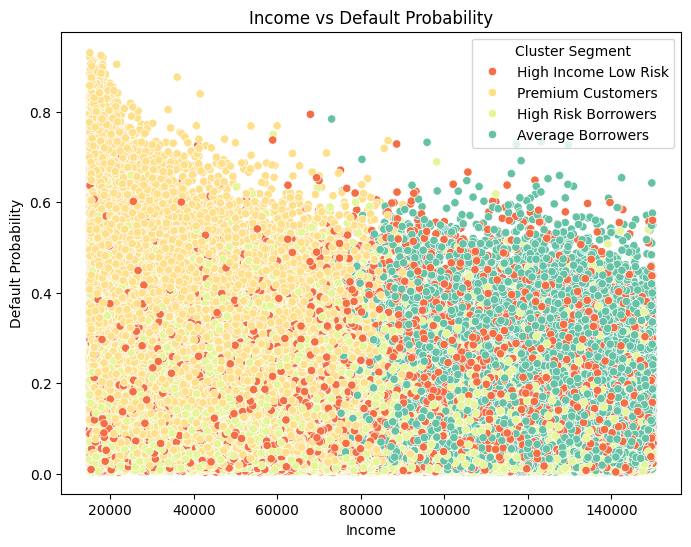

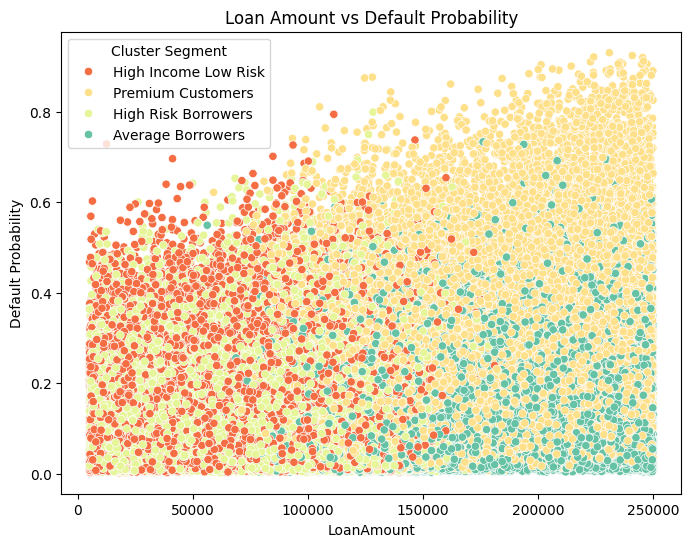

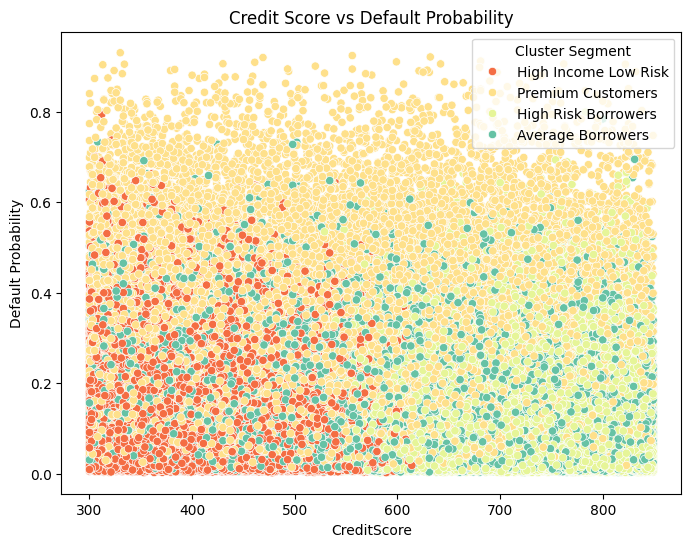


Cluster Segment
Average Borrowers       64028
Premium Customers       63922
High Income Low Risk    63879
High Risk Borrowers     63518
Name: count, dtype: int64

Average Default Probability By Segment

Cluster Segment
Premium Customers       0.213465
Average Borrowers       0.122937
High Income Low Risk    0.116598
High Risk Borrowers     0.103157
Name: Default Probability, dtype: float32


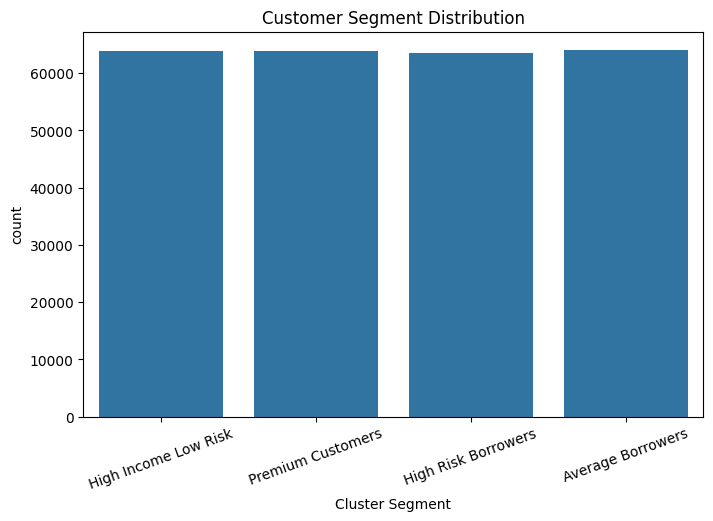


Project Completed Successfully


In [21]:
# ============================================================
# PART 9 : CUSTOMER RISK SEGMENTATION USING K-MEANS
# ============================================================

scaler = StandardScaler()

cluster_features = segmentation_data[

    [

        'Income',

        'LoanAmount',

        'CreditScore'

    ]

]

scaled_data = scaler.fit_transform(

    cluster_features

)

print(scaled_data[:5])

# Elbow Method

wcss = []

for k in range(1,16):

    kmeans = KMeans(

        n_clusters=k,

        random_state=42,

        n_init=10

    )

    kmeans.fit(

        scaled_data

    )

    wcss.append(

        kmeans.inertia_

    )

plt.figure(figsize=(8,6))

plt.plot(

    range(1,16),

    wcss,

    marker='o'

)

plt.xlabel(

    "Number of Clusters (K)"

)

plt.ylabel(

    "WCSS"

)

plt.title(

    "Elbow Method"
)

plt.show()

# Final Clustering

kmeans = KMeans(

    n_clusters=4,

    random_state=42,

    n_init=10

)

clusters = kmeans.fit_predict(

    scaled_data

)

segmentation_data['Cluster'] = clusters

cluster_summary = segmentation_data.groupby(

    'Cluster'

).mean(

    numeric_only=True

)

print()

print("Cluster Summary")

print()

print(cluster_summary)

# Cluster Names

cluster_names = {

    0 : 'High Income Low Risk',

    1 : 'High Risk Borrowers',

    2 : 'Premium Customers',

    3 : 'Average Borrowers'

}

segmentation_data['Cluster Segment'] = (

    segmentation_data['Cluster']

    .map(

        cluster_names

    )

)

print()

print(segmentation_data.head())

# ============================================================
# INCOME VS DEFAULT PROBABILITY
# ============================================================

plt.figure(figsize=(8,6))

sns.scatterplot(

    x='Income',

    y='Default Probability',

    hue='Cluster Segment',

    data=segmentation_data,

    palette='Spectral'

)

plt.title(

    "Income vs Default Probability"

)

plt.show()

# ============================================================
# LOAN AMOUNT VS DEFAULT PROBABILITY
# ============================================================

plt.figure(figsize=(8,6))

sns.scatterplot(

    x='LoanAmount',

    y='Default Probability',

    hue='Cluster Segment',

    data=segmentation_data,

    palette='Spectral'

)

plt.title(

    "Loan Amount vs Default Probability"

)

plt.show()

# ============================================================
# CREDIT SCORE VS DEFAULT PROBABILITY
# ============================================================

plt.figure(figsize=(8,6))

sns.scatterplot(

    x='CreditScore',

    y='Default Probability',

    hue='Cluster Segment',

    data=segmentation_data,

    palette='Spectral'

)

plt.title(

    "Credit Score vs Default Probability"

)

plt.show()

# ============================================================
# CLUSTER COUNTS
# ============================================================

print()

print(

    segmentation_data[
        'Cluster Segment'
    ].value_counts()

)

# ============================================================
# AVERAGE DEFAULT PROBABILITY BY SEGMENT
# ============================================================

risk_summary = segmentation_data.groupby(

    'Cluster Segment'

)[

    'Default Probability'

].mean()

print()

print(

    "Average Default Probability By Segment"

)

print()

print(

    risk_summary.sort_values(

        ascending=False

    )

)

# ============================================================
# SEGMENT DISTRIBUTION
# ============================================================

plt.figure(figsize=(8,5))

sns.countplot(

    x='Cluster Segment',

    data=segmentation_data

)

plt.xticks(

    rotation=20

)

plt.title(

    "Customer Segment Distribution"

)

plt.show()

print()

print("Project Completed Successfully")